In [2]:
import pandas as pd
import matplotlib.pyplot as plt

ri = pd.read_csv('RI_cleaned.csv', nrows=50000)
weather = pd.read_csv("weather.csv")

drop_columns=["state", "county_name", "county_fips", "fine_grained_location"]
ri.drop(drop_columns, axis='columns', inplace=True)

ri.dropna(subset=['driver_gender'], inplace=True)

ri['is_arrested'] = ri.is_arrested.astype('bool')

combined = ri.stop_date.str.cat(ri.stop_time, sep=' ')
ri['stop_datetime'] = pd.to_datetime(combined)


ri.set_index('stop_datetime', inplace=True)

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_11331/4113376902.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  ri = pd.read_csv('RI_cleaned.csv', nrows=50000)


<h1><p style="text-align: center;">Datenanalyse mit Python <br>Projekt – 1</p></h1> <h1>- Polizeikontrollen im Straßenverkehr </h1>

# Wetter und Polizeiverhalten bei Verkehrskontrollen

In diesem Kapitel verwenden Sie einen **zweiten Datensatz**,  
um den Einfluss von **Wetterbedingungen** auf das Verhalten der Polizei bei Verkehrskontrollen zu untersuchen.

Sie üben das **Zusammenführen** und **Umformen** von Datensätzen,  
bewerten die Vertrauenswürdigkeit einer Datenquelle,  
arbeiten mit **kategorialen Daten** und wenden weitere fortgeschrittene Techniken an.

## 1. Temperatur visualisieren

In dieser Übung untersuchen Sie die Spalten ``temperature`` aus dem ``weather``-Datensatz,  
um einzuschätzen, ob die Daten vertrauenswürdig erscheinen.  

Zuerst geben Sie die **Zusammenfassungsstatistiken** aus und visualisieren die Daten dann mit einem **Boxplot**.

Beachten Sie bei der Bewertung, ob die Werte sinnvoll sind,  
dass die Temperatur in **Fahrenheit** und nicht in Celsius gemessen wird!

**ANWEISUNGEN**

*   Lesen Sie die Datei ``weather.csv`` in ein ``DataFrame`` mit dem Namen ``weather`` ein.
*   Wählen Sie die Temperatursäulen (``TMIN``, ``TAVG``, ``TMAX``) aus und geben Sie deren ``summary statistics`` mit der Methode ``.describe()`` aus.
*   Erstellen Sie ein **Boxplot**, um die Temperaturspalten zu visualisieren.
*   Zeigen Sie das Diagramm an.

In [3]:
weather.head()

,STATION,DATE,AWND,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,...,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22
0,USC00379423,2005-01-01,NaN,NaN,47.0,28.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USC00379423,2005-01-02,NaN,NaN,52.0,24.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USC00379423,2005-01-03,NaN,NaN,48.0,27.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USC00379423,2005-01-04,NaN,NaN,54.0,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USC00379423,2005-01-05,NaN,NaN,44.0,31.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
weather.shape

(8022, 26)

In [4]:
weather.tail()

,STATION,DATE,AWND,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,...,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22
8017,USW00014765,2015-12-27,9.17,51.0,61.0,44.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8018,USW00014765,2015-12-28,12.30,40.0,44.0,30.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8019,USW00014765,2015-12-29,12.53,33.0,40.0,28.0,1.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8020,USW00014765,2015-12-30,6.93,30.0,35.0,27.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8021,USW00014765,2015-12-31,8.05,39.0,50.0,35.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
weather[["TMIN", "TAVG", "TMAX"]]

,TMIN,TAVG,TMAX
0,28.0,NaN,47.0
1,24.0,NaN,52.0
2,27.0,NaN,48.0
3,40.0,NaN,54.0
4,31.0,NaN,44.0
...,...,...,...
8017,44.0,51.0,61.0
8018,30.0,40.0,44.0
8019,28.0,33.0,40.0
8020,27.0,30.0,35.0


> **TMIN**: Tagestiefsttemperatur (in °F)  
**TAVG**: Tagesdurchschnittstemperatur  
**TMAX**: Tageshöchsttemperatur  


In [7]:
weather[["TMIN", "TAVG", "TMAX"]].describe()

,TMIN,TAVG,TMAX
count,7996.000000,1217.000000,8005.000000
mean,42.099425,52.493016,61.247096
std,17.386667,17.829792,18.495043
min,-10.000000,6.000000,13.000000
25%,29.000000,39.000000,46.000000
50%,42.000000,54.000000,62.000000
75%,57.000000,68.000000,77.000000
max,77.000000,86.000000,102.000000


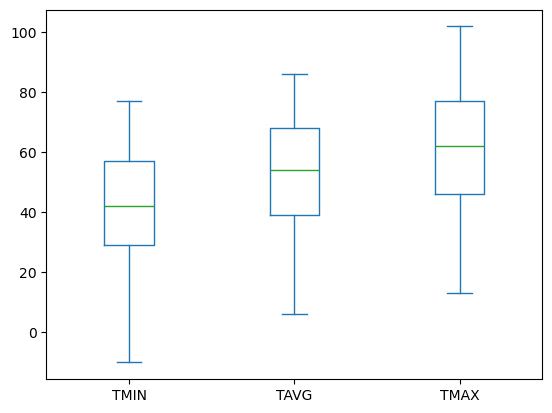

In [9]:
# Boxplot zur Darstellung der Temperaturwerte (inkl. Ausreißer)
weather[["TMIN", "TAVG", "TMAX"]].plot(kind="box")

# Diagramm anzeigen
plt.show()

***

## 2. Darstellung der Temperaturdifferenz


In dieser Übung überprüfen Sie weiterhin, ob der Datensatz vertrauenswürdig erscheint,  
indem Sie die Differenz zwischen der maximalen und minimalen Temperatur darstellen.

Was fällt Ihnen beim resultierenden **Histogramm** auf?  
Entspricht es Ihren Erwartungen oder gibt es ungewöhnliche Auffälligkeiten?

**ANWEISUNGEN**

*   Erstellen Sie eine neue Spalte im ``weather``-``DataFrame`` mit dem Namen ``TDIFF``,  
    die die Differenz zwischen maximaler und minimaler Temperatur darstellt.
*   Geben Sie die ``summary statistics`` für ``TDIFF`` mit der Methode ``.describe()`` aus.
*   Erstellen Sie ein Histogramm mit ``20 bins``, um ``TDIFF`` zu visualisieren.
*   Zeigen Sie das Diagramm an.

In [10]:
weather["TMAX"] 

0       47.0
1       52.0
2       48.0
3       54.0
4       44.0
        ... 
8017    61.0
8018    44.0
8019    40.0
8020    35.0
8021    50.0
Name: TMAX, Length: 8022, dtype: float64

In [11]:
weather["TMIN"] 

0       28.0
1       24.0
2       27.0
3       40.0
4       31.0
        ... 
8017    44.0
8018    30.0
8019    28.0
8020    27.0
8021    35.0
Name: TMIN, Length: 8022, dtype: float64

In [12]:
weather["TMAX"] - weather["TMIN"] 

0       19.0
1       28.0
2       21.0
3       14.0
4       13.0
        ... 
8017    17.0
8018    14.0
8019    12.0
8020     8.0
8021    15.0
Length: 8022, dtype: float64

In [13]:
weather["TDIFF"] = weather["TMAX"] - weather["TMIN"] 

In [14]:
weather.TDIFF.describe()

count    7994.000000
mean       19.149237
std         7.009716
min       -25.000000
25%        14.000000
50%        19.000000
75%        24.000000
max        48.000000
Name: TDIFF, dtype: float64

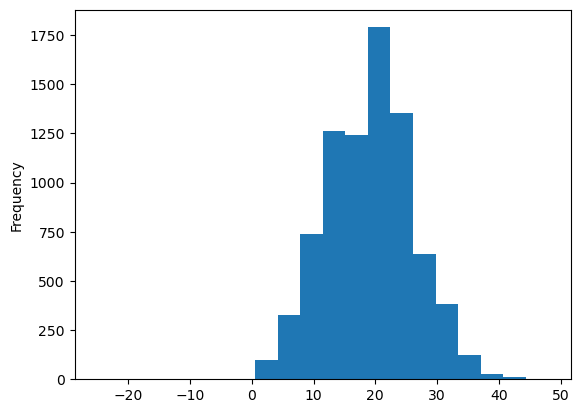

In [15]:
weather.TDIFF.plot(kind="hist", bins=20)

plt.show()

> **Was ist TDIFF?**  
TDIFF = TMAX − TMIN → Temperaturunterschied pro Tag.

> **Wofür ist das nützlich?**  
Zeigt, wie stark sich das Wetter innerhalb eines Tages verändert hat  
und hilft, die Datenqualität zu prüfen.

> **Sind die Daten vertrauenswürdig?**  
→ Meistens ja, aber es gibt negative Werte (z. B. TDIFF = −25),  
was nicht möglich ist (TMAX < TMIN) → Eingabefehler.

> **Fazit:**  
Daten sind größtenteils sinnvoll, aber einige Ausreißer müssen bereinigt werden.


***

## 3. Zählen schlechter Wetterbedingungen

Das ``weather``-``DataFrame`` enthält ``20`` Spalten, die mit ``'WT'`` beginnen –  
jede davon steht für eine bestimmte schlechte Wetterbedingung. Zum Beispiel:

*   ``WT05`` steht für ``"Hagel"``
*   ``WT11`` steht für ``"starker oder schädigender Wind"``
*   ``WT17`` steht für ``"Eisregen"``

In jeder Zeile enthält jede ``WT``-Spalte entweder eine ``1`` (die Bedingung war an diesem Tag vorhanden)  
oder ``NaN`` (die Bedingung war nicht vorhanden).

In dieser Übung quantifizieren Sie, **wie schlecht** das Wetter an einem Tag war,  
indem Sie die Anzahl der ``1``-Werte pro Zeile zählen.

**ANWEISUNGEN**

*   Kopieren Sie die Spalten ``WT01`` bis ``WT22`` aus ``weather`` in ein neues ``DataFrame`` namens ``WT``.
*   Berechnen Sie die Summe jeder Zeile in ``WT`` und speichern Sie das Ergebnis in einer neuen Spalte im ``weather``-``DataFrame`` mit dem Namen ``bad_conditions``.
*   Ersetzen Sie alle ``missing values`` in ``bad_conditions`` durch ``0``. (Dies wurde bereits für Sie erledigt.)
*   Erstellen Sie ein **Histogramm**, um ``bad_conditions`` zu visualisieren, und zeigen Sie das Diagramm an.

In [17]:
weather.head()

,STATION,DATE,AWND,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,...,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22,TDIFF
0,USC00379423,2005-01-01,NaN,NaN,47.0,28.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0
1,USC00379423,2005-01-02,NaN,NaN,52.0,24.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0
2,USC00379423,2005-01-03,NaN,NaN,48.0,27.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0
3,USC00379423,2005-01-04,NaN,NaN,54.0,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0
4,USC00379423,2005-01-05,NaN,NaN,44.0,31.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0


In [18]:
WT = weather.loc[:, "WT01":"WT22"]

In [19]:
WT.head(3)

,WT01,WT02,WT03,WT04,WT05,WT06,WT07,WT08,WT09,WT10,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# Summe der schlechten Wetterbedingungen pro Tag berechnen und in ``bad_conditions`` speichern
weather["bad_conditions"] = WT.sum(axis="columns")


In [22]:
weather.head()

,STATION,DATE,AWND,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,...,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22,TDIFF,bad_conditions
0,USC00379423,2005-01-01,NaN,NaN,47.0,28.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0,0.0
1,USC00379423,2005-01-02,NaN,NaN,52.0,24.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,0.0
2,USC00379423,2005-01-03,NaN,NaN,48.0,27.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,0.0
3,USC00379423,2005-01-04,NaN,NaN,54.0,40.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,0.0
4,USC00379423,2005-01-05,NaN,NaN,44.0,31.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,0.0


In [23]:
weather.sample(5)

,STATION,DATE,AWND,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,...,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22,TDIFF,bad_conditions
3811,USC00379423,2015-07-03,NaN,NaN,80.0,57.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,0.0
2417,USC00379423,2011-08-31,NaN,NaN,81.0,55.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,0.0
6480,USW00014765,2011-10-12,8.72,NaN,61.0,53.0,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,8.0,3.0
888,USC00379423,2007-06-16,NaN,NaN,73.0,60.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,0.0
7121,USW00014765,2013-07-14,6.04,80.0,92.0,72.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1.0


In [24]:
# Fehlende Werte durch 0 ersetzen und in ganze Zahlen (int) umwandeln
weather["bad_conditions"] = weather.bad_conditions.fillna(0).astype("int")

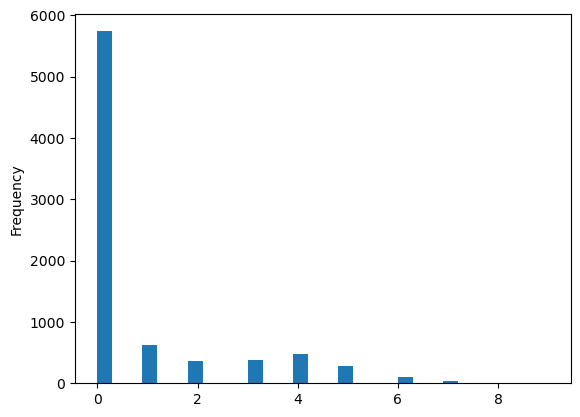

In [25]:
weather.bad_conditions.plot(kind="hist", bins=30)

plt.show()

In [26]:
# Häufigkeit jeder Anzahl schlechter Wetterbedingungen anzeigen (inkl. fehlender Werte, falls vorhanden)
weather.bad_conditions.value_counts(dropna=False)

bad_conditions
0    5738
1     628
4     476
3     380
2     368
5     282
6     101
7      41
9       4
8       4
Name: count, dtype: int64

### 📊 Histogramm-Auswertung: Schlechte Wetterbedingungen

#### ✅ Beobachtungen:

- An über **6000 Tagen** wurden **keine schlechten Wetterbedingungen** verzeichnet (`bad_conditions = 0`).
- Tage mit schlechten Wetterbedingungen sind **selten** und gleichmäßig verteilt.
- Maximal wurden an einem Tag **8 verschiedene schlechte Wetterarten** beobachtet – das ist eine Ausnahme.

#### 🔍 Fazit zur Datenqualität:

- Die Verteilung erscheint **realistisch und vertrauenswürdig**.
- Kein Hinweis auf fehlerhafte Daten oder Ausreißer.
- Die Datenbasis ist geeignet für weiterführende Analysen.


***

## 4. Bewertung der Wetterbedingungen

In der vorherigen Übung haben Sie gezählt, wie viele schlechte Wetterbedingungen pro Tag aufgetreten sind.  
In dieser Übung verwenden Sie diese Anzahl, um ein *Bewertungssystem* für das Wetter zu erstellen.

Die Anzahl reicht von ``0`` bis ``9`` und soll folgendermaßen in Bewertungen umgewandelt werden:

*   ``0`` → ``'good'``
*   ``1`` bis ``4`` → ``'bad'``
*   ``5`` bis ``9`` → ``'worse'``

**ANWEISUNGEN**

*   Zählen Sie die **unique** Werte in der Spalte ``bad_conditions`` und sortieren Sie den ``index``.
*   Erstellen Sie ein ``dictionary`` namens ``mapping``, das die ``bad_conditions``-Integer gemäß den obigen Vorgaben in Strings umwandelt.
*   Wandeln Sie die ``bad_conditions``-Integer mithilfe von ``mapping`` in Strings um  
    und speichern Sie das Ergebnis in einer neuen Spalte namens ``rating``.
*   Zählen Sie die **unique** Werte in ``rating``, um zu überprüfen, ob die Umwandlung korrekt war.

In [28]:
# Anzahl der Tage pro Wert in ``bad_conditions``, sortiert nach Wert
weather.bad_conditions.value_counts().sort_index()

bad_conditions
0    5738
1     628
2     368
3     380
4     476
5     282
6     101
7      41
8       4
9       4
Name: count, dtype: int64

In [29]:
mapping = {0:"good", 1:"bad", 2:"bad", 3:"bad", 4:"bad", 5:"worse", 6:"worse", 7:"worse", 8:"worse", 9:"worse"}

In [30]:
weather["rating"] = weather.bad_conditions.map(mapping)

In [72]:
weather.rating.value_counts()

good     5738
bad      1852
worse     432
Name: rating, dtype: int64

***

## 5. Änderung des Datentyps zu Kategorie

Da die Spalte ``rating`` nur wenige mögliche Werte enthält,  
werden Sie ihren Datentyp in ``category`` ändern, um die Daten effizienter zu speichern.  

Außerdem legen Sie eine logische Reihenfolge für die Kategorien fest,  
was in den folgenden Übungen nützlich sein wird.

**ANWEISUNGEN**

*   Erstellen Sie ein ``list``-Objekt namens ``cats``, das die Wetterbewertungen in logischer Reihenfolge enthält: ``'good'``, ``'bad'``, ``'worse'``.
*   Ändern Sie den Datentyp der Spalte ``rating`` von ``object`` zu ``category``.  
    Verwenden Sie dabei die ``cats``-Liste, um die Reihenfolge der Kategorien festzulegen.
*   Prüfen Sie mit ``.head()``, ob die Kategorien in der Spalte ``rating`` korrekt und logisch geordnet sind.

In [31]:
weather.rating[0]

'good'

In [32]:
type(weather.rating[0])

str

In [33]:
# Kategorien in logischer Reihenfolge festlegen
categ = ["good", "bad", "worse"]

In [34]:
# Spalte ``rating`` in einen kategorischen Datentyp mit definierter Reihenfolge umwandeln
weather["rating"] = pd.Categorical(weather.rating, categories=categ, ordered=True)


In [35]:
weather.rating.head()

0    good
1    good
2    good
3    good
4    good
Name: rating, dtype: category
Categories (3, object): ['good' < 'bad' < 'worse']

***

## 6. DataFrames vorbereiten


In dieser Übung bereiten Sie die ``DataFrames`` **traffic stop** und **weather rating** so vor,  
dass sie für das Zusammenführen bereit sind:

Beim ``ri``-``DataFrame`` verschieben Sie den ``stop_datetime``-Index in eine eigene ``Spalte``,  
da der Index beim Merge verloren geht.

Beim ``weather``-``DataFrame`` wählen Sie die Spalten ``DATE`` und ``rating`` aus  
und speichern sie in einem neuen ``DataFrame``.

**ANWEISUNGEN**

* Setzen Sie den ``index`` des ``ri``-``DataFrame`` zurück.

* Überprüfen Sie mit ``head()``, ob ``stop_datetime`` nun eine Spalte im ``DataFrame`` ist  
  und ob der ``index`` jetzt ein Standard-``Integer``-Index ist.

* Erstellen Sie ein neues ``DataFrame`` namens ``weather_rating``,  
  das nur die Spalten ``DATE`` und ``rating`` aus dem ``weather``-``DataFrame`` enthält.

* Überprüfen Sie mit ``head()``, ob ``weather_rating`` die richtigen Spalten enthält.

> Bevor Sie mit diesem Abschnitt des Kapitels beginnen, **wiederholen Sie die Schritte zur Vorbereitung der ``ri``-Daten,  
die Sie bereits im ersten Kapitel durchgeführt haben.**  
Fahren Sie mit diesem Kapitel auf Grundlage des Endstandes aus Kapitel 1 fort.

In [36]:
# Index zurücksetzen – ``stop_datetime`` wird zur Spalte
ri.reset_index(inplace=True)

In [37]:
weather.head(3)

,STATION,DATE,AWND,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,...,WT15,WT16,WT17,WT18,WT19,WT21,WT22,TDIFF,bad_conditions,rating
0,USC00379423,2005-01-01,NaN,NaN,47.0,28.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.0,0,good
1,USC00379423,2005-01-02,NaN,NaN,52.0,24.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,0,good
2,USC00379423,2005-01-03,NaN,NaN,48.0,27.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,0,good


In [38]:
weather.columns

Index(['STATION', 'DATE', 'AWND', 'TAVG', 'TMAX', 'TMIN', 'WT01', 'WT02',
       'WT03', 'WT04', 'WT05', 'WT06', 'WT07', 'WT08', 'WT09', 'WT10', 'WT11',
       'WT13', 'WT14', 'WT15', 'WT16', 'WT17', 'WT18', 'WT19', 'WT21', 'WT22',
       'TDIFF', 'bad_conditions', 'rating'],
      dtype='object')

In [39]:
weather_rating = weather[["DATE", "rating"]]

In [40]:
weather.rating.head()

0    good
1    good
2    good
3    good
4    good
Name: rating, dtype: category
Categories (3, object): ['good' < 'bad' < 'worse']

***

## 7. DataFrames zusammenführen

### Zusammenführen (merging) der DataFrames

In dieser Übung führen Sie die ``DataFrames`` ``ri`` und ``weather_rating``  
zu einem neuen ``DataFrame`` namens ``ri_weather`` zusammen.

Die ``DataFrames`` werden über die Spalten ``stop_date`` aus ``ri``  
und ``DATE`` aus ``weather_rating`` verknüpft.  
Glücklicherweise stimmen die Datumsformate exakt überein – was nicht immer der Fall ist!

Nach dem Merge setzen Sie ``stop_datetime`` (die zuvor gespeicherte Spalte)  
wieder als Index.

Examine the shape of the ``ri`` ``DataFrame``.
``Merge`` the ``ri`` and ``weather_rating`` ``DataFrames`` using a ``left join``.
Examine the ``shape`` of ``ri_weather`` to confirm that it has two more columns but the same number of rows as ``ri``.
Replace the ``index`` of ``ri_weather`` with the ``stop_datetime`` column.

In [41]:
ri.shape

(48010, 23)

In [42]:
# DataFrames über Datum zusammenführen (merging)
ri_weather = pd.merge(left = ri, right = weather_rating, left_on="stop_date", right_on="DATE", how = "left")

In [43]:
# Durch das Merge hat sich die Zeilenanzahl fast verdoppelt
ri_weather.shape

(95877, 25)

In [44]:
ri_weather.head()

,stop_datetime,id,stop_date,stop_time,location_raw,police_department,driver_gender,driver_age_raw,driver_age,driver_race_raw,...,search_type,contraband_found,stop_outcome,is_arrested,stop_duration,out_of_state,drugs_related_stop,district,DATE,rating
0,2005-01-02 01:55:00,RI-2005-00001,2005-01-02,01:55,Zone K1,600,M,1985.0,20.0,W,...,NaN,False,Citation,False,0-15 Min,False,False,Zone K1,2005-01-02,good
1,2005-01-02 01:55:00,RI-2005-00001,2005-01-02,01:55,Zone K1,600,M,1985.0,20.0,W,...,NaN,False,Citation,False,0-15 Min,False,False,Zone K1,2005-01-02,bad
2,2005-01-02 20:30:00,RI-2005-00002,2005-01-02,20:30,Zone X4,500,M,1987.0,18.0,W,...,NaN,False,Citation,False,16-30 Min,False,False,Zone X4,2005-01-02,good
3,2005-01-02 20:30:00,RI-2005-00002,2005-01-02,20:30,Zone X4,500,M,1987.0,18.0,W,...,NaN,False,Citation,False,16-30 Min,False,False,Zone X4,2005-01-02,bad
4,2005-01-04 12:55:00,RI-2005-00004,2005-01-04,12:55,Zone X4,500,M,1986.0,19.0,W,...,NaN,False,Citation,False,0-15 Min,False,False,Zone X4,2005-01-04,good


In [45]:
ri_weather.set_index("stop_datetime", inplace=True)

***

## 8. Vergleich der Verhaftungsraten nach Wetterbewertung


Verhaften Polizeibeamte Fahrer häufiger bei schlechtem Wetter? Finden Sie es heraus!

- **Zuerst** berechnen Sie die **allgemeine Verhaftungsrate**.

- **Dann** berechnen Sie die **Verhaftungsrate** für jede der zuvor zugewiesenen **Wetterbewertungen**.

- **Schließlich** fügen Sie die **Verstoßart** als zweiten Faktor hinzu,  
  um zu sehen, ob sie Unterschiede in der Verhaftungsrate erklären kann.

Da Sie zuvor eine logische Reihenfolge für die Wetterkategorien definiert haben  
(``good < bad < worse``), werden die Ergebnisse entsprechend sortiert angezeigt.

In [47]:
# Durchschnitt der Spalte ``is_arrested`` berechnen - allgemeine Verhaftungsrate
ri_weather.is_arrested.mean()

0.05181638974936638

In [48]:
# Verhaftungsrate pro Wetterbewertung berechnen
ri_weather.groupby("rating").is_arrested.mean()

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_11331/2903628514.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ri_weather.groupby("rating").is_arrested.mean()


rating
good     0.051263
bad      0.051462
worse    0.062559
Name: is_arrested, dtype: float64

In [49]:
# Verhaftungsrate nach Verstoßtyp und Wetterbewertung berechnen
ri_weather.groupby(["violation", "rating"]).is_arrested.mean()

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_11331/1038247774.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ri_weather.groupby(["violation", "rating"]).is_arrested.mean()


violation            rating
Equipment            good      0.121123
                     bad       0.125000
                     worse     0.150943
Moving violation     good      0.114006
                     bad       0.116299
                     worse     0.133835
Other                good      0.275689
                     bad       0.283368
                     worse     0.270833
Registration/plates  good      0.196108
                     bad       0.214286
                     worse     0.166667
Speeding             good      0.023061
                     bad       0.021220
                     worse     0.026168
Name: is_arrested, dtype: float64

***

## 9. Auswahl aus einer Series mit MultiIndex

Das Ergebnis einer ``.groupby()``-Operation über mehrere Spalten ist eine ``Series`` mit einem ``MultiIndex``.  
Die Arbeit mit diesem Objekttyp ähnelt der Arbeit mit einem ``DataFrame``:

Die äußere Indexebene entspricht den Zeilen eines ``DataFrame``  
Die innere Indexebene entspricht den Spalten eines ``DataFrame``

In dieser Übung üben Sie, mit dem ``.loc[]``-Accessor auf Daten aus einer Multi-Index-``Series`` zuzugreifen.

**ANWEISUNGEN**

- Speichern Sie das Ergebnis der ``.groupby()``-Operation aus der vorherigen Übung als neues Objekt ``arrest_rate``.
- Geben Sie die ``arrest_rate``-``Series`` aus und untersuchen Sie sie.
- Geben Sie die Verhaftungsrate für ``moving violations`` bei schlechtem Wetter aus.
- Geben Sie die Verhaftungsraten für ``speeding violations`` unter allen drei Wetterbedingungen aus.

In [50]:
# Verhaftungsrate nach Verstoßtyp und Wetterbewertung berechnen und als Series speichern
arrest_rate = ri_weather.groupby(["violation", "rating"]).is_arrested.mean()

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_11331/1185304052.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arrest_rate = ri_weather.groupby(["violation", "rating"]).is_arrested.mean()


In [51]:
arrest_rate

violation            rating
Equipment            good      0.121123
                     bad       0.125000
                     worse     0.150943
Moving violation     good      0.114006
                     bad       0.116299
                     worse     0.133835
Other                good      0.275689
                     bad       0.283368
                     worse     0.270833
Registration/plates  good      0.196108
                     bad       0.214286
                     worse     0.166667
Speeding             good      0.023061
                     bad       0.021220
                     worse     0.026168
Name: is_arrested, dtype: float64

***

## 10. Verhaftungsraten umstrukturieren

In dieser Übung beginnen Sie damit, die ``arrest_rate``-``Series`` in ein ``DataFrame`` umzuwandeln.  
Das ist ein nützlicher Schritt beim Arbeiten mit einer ``Series`` mit ``MultiIndex``,  
da dadurch die vollständige Nutzung der ``DataFrame``-Methoden möglich wird.

Anschließend erstellen Sie genau dasselbe ``DataFrame`` mithilfe einer ``Pivot-Tabelle``.  
Das ist ein gutes Beispiel dafür, dass pandas oft mehrere Wege zum gleichen Ergebnis bietet!

**ANWEISUNGEN**

- Verwenden Sie ``unstack``, um die ``arrest_rate``-``Series`` in ein ``DataFrame`` umzuwandeln.
- Erstellen Sie dasselbe ``DataFrame`` mithilfe einer ``Pivot-Tabelle``!  
  Jeder der drei ``.pivot_table()``-Parameter sollte einer der Spalten von ``ri_weather`` entsprechen.

In [96]:
arrest_rate.unstack()  # pandas serie'sini dataframe'e çevirdik

rating,good,bad,worse
violation,,,
Equipment,0.121123,0.125000,0.150943
Moving violation,0.114006,0.116299,0.133835
Other,0.275689,0.283368,0.270833
Registration/plates,0.196108,0.214286,0.166667
Speeding,0.023061,0.021220,0.026168


In [52]:
# Pivot-Tabelle zur Darstellung der Verhaftungsraten nach Verstoß und Wetterbewertung
# Standard-Aggregation ist ``mean``
ri_weather.pivot_table(index="violation", columns="rating", values="is_arrested")

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_11331/1815002885.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ri_weather.pivot_table(index="violation", columns="rating", values="is_arrested")


rating,good,bad,worse
violation,,,
Equipment,0.121123,0.125000,0.150943
Moving violation,0.114006,0.116299,0.133835
Other,0.275689,0.283368,0.270833
Registration/plates,0.196108,0.214286,0.166667
Speeding,0.023061,0.021220,0.026168


In [53]:
# Transponieren der Pivot-Tabelle – Zeilen und Spalten tauschen
ri_weather.pivot_table(index="violation", columns="rating", values="is_arrested").T

/var/folders/bb/6m7zfmqn4dlckynjdkxpvrrr0000gn/T/ipykernel_11331/3604335987.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  ri_weather.pivot_table(index="violation", columns="rating", values="is_arrested").T


violation,Equipment,Moving violation,Other,Registration/plates,Speeding
rating,,,,,
good,0.121123,0.114006,0.275689,0.196108,0.023061
bad,0.125000,0.116299,0.283368,0.214286,0.021220
worse,0.150943,0.133835,0.270833,0.166667,0.026168


### 🟢 Fazit

In dieser Analyse wurde untersucht, ob sich das Verhalten der Polizei – insbesondere die Verhaftungsrate –  
in Abhängigkeit von den Wetterbedingungen verändert.  

Die Ergebnisse zeigen, dass bei schlechterem Wetter tendenziell häufiger Verhaftungen erfolgen,  
besonders bei bestimmten Verstößen wie z. B. ``Moving violations`` oder ``Speeding``.

Durch den Einsatz von MultiIndex, Pivot-Tabellen und kategorischen Daten  
konnten komplexe Zusammenhänge übersichtlich dargestellt werden.